In [42]:
"""

Metricas a evaluar de cada modelo: 

- R² (coeficiente de determinación)
- Error cuadrático medio (MSE)
- Raíz del error cuadrático medio (RMSE)
- Error absoluto medio (MAE)
- Error porcentual absoluto medio (MAPE)
- R2 ajustado

"""

'\n\nMetricas a evaluar de cada modelo: \n\n- R² (coeficiente de determinación)\n- Error cuadrático medio (MSE)\n- Raíz del error cuadrático medio (RMSE)\n- Error absoluto medio (MAE)\n- Error porcentual absoluto medio (MAPE)\n- R2 ajustado\n\n'

# Carga de Librerias

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

# Carga del archivo


In [ ]:
#carga del archivooo
mpg = pd.read_csv('data/autoMPG/auto-mpg.csv')
mpg = mpg.dropna() #para borrar nulos 
for i in mpg.columns:
    for j in mpg[i]:
        if not isinstance(j, (int, float)):
            mpg[i] = mpg[i].replace(j, 0)

#division en x e y
mpg_x = mpg.drop(['mpg', 'car name'], axis=1)
mpg_y = mpg['mpg']

#division de los datos en entrenamiento yyy prueba
x_train, x_test, y_train, y_test = train_test_split(mpg_x, mpg_y, test_size = 0.2, random_state=42)


# Regresión Lineal


Coeficientes del modelo: 
1. R cuadrado: 0.8473
2. Error cuadrático medio (MSE): 8.2099
3. Raíz del error cuadrático medio (RMSE): 2.8653
4. Error absoluto medio (MAE): 2.2468
5. Error porcentual absoluto medio (MAPE): 9.7087
6. R cuadrado ajustado: 0.8325


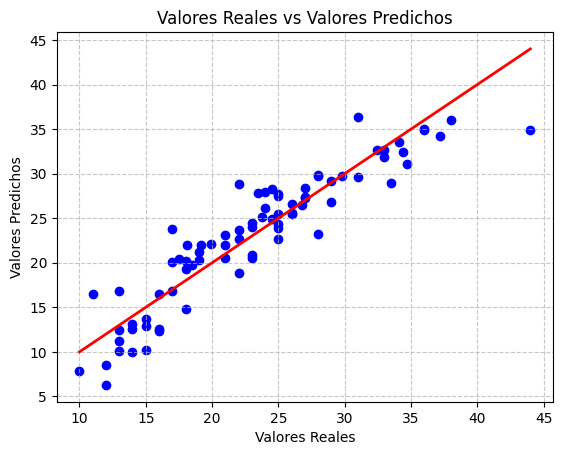

In [45]:
#entrenamiento del modelo
lineal = LinearRegression()
lineal.fit(x_train, y_train)

mpg_predict = lineal.predict(x_test)

R2_L = r2_score(y_test, mpg_predict)
R2_ajustada_L = 1 - (1 - R2_L) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)
MSE_L = mean_squared_error(y_test, mpg_predict)
RMSE_L = MSE_L ** 0.5
MAE_L = mean_absolute_error(y_test, mpg_predict)
MAPE_L = (MAE_L / y_test.mean()) * 100

#Metricas de la predicción
print("Coeficientes del modelo: ")
print(f"1. R cuadrado: {R2_L:.4f}")
print(f"2. Error cuadrático medio (MSE): {MSE_L:.4f}")
print(f"3. Raíz del error cuadrático medio (RMSE): {RMSE_L:.4f}")
print(f"4. Error absoluto medio (MAE): {MAE_L:.4f}")
print(f"5. Error porcentual absoluto medio (MAPE): {MAPE_L:.4f}")
print(f"6. R cuadrado ajustado: {R2_ajustada_L:.4f}")

#grafica
plt.scatter(y_test, mpg_predict, color='blue')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Reales vs Valores Predichos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.show()


# Random Forest 

In [46]:
#Entrenamiento del modelo
rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
rf.fit(x_train, y_train)
mpg_predict_rf = rf.predict(x_test)

#Metricas de la prediccion
R2_RF = r2_score(y_test, mpg_predict_rf)
MSE_RF = mean_squared_error(y_test, mpg_predict_rf)
RMSE_RF = MSE_RF ** 0.5
MAE_RF = mean_absolute_error(y_test, mpg_predict_rf)
MAPE_RF = (MAE_RF / y_test.mean()) * 100
R2_ajustada_RF = 1 - (1 - R2_RF) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)

print("Coeficientes del modelo: ")
print(f"1. R cuadrado: {R2_RF:.4f}")
print(f"2. Error cuadrático medio (MSE): {MSE_RF:.4f}")
print(f"3. Raíz del error cuadrático medio (RMSE): {RMSE_RF:.4f}")
print(f"4. Error absoluto medio (MAE): {MAE_RF:.4f}")
print(f"5. Error porcentual absoluto medio (MAPE): {MAPE_RF:.4f}")
print(f"6. R cuadrado ajustado: {R2_ajustada_RF:.4f}")

Coeficientes del modelo: 
1. R cuadrado: 0.9087
2. Error cuadrático medio (MSE): 4.9079
3. Raíz del error cuadrático medio (RMSE): 2.2154
4. Error absoluto medio (MAE): 1.6334
5. Error porcentual absoluto medio (MAPE): 7.0579
6. R cuadrado ajustado: 0.8998


# K - Nearest Neighbors 

In [47]:
#Entrenamiento del modelooo
vecinos = KNeighborsRegressor(n_neighbors=5)
vecinos.fit(x_train, y_train)

mpg_predict_knn = vecinos.predict(x_test)

#Metricas de la prediccion
R2_KNN = r2_score(y_test, mpg_predict_knn)
MSE_KNN = mean_squared_error(y_test, mpg_predict_knn)
RMSE_KNN = MSE_KNN ** 0.5
MAE_KNN = mean_absolute_error(y_test, mpg_predict_knn)
MAPE_KNN = (MAE_KNN / y_test.mean()) * 100
R2_ajustada_KNN = 1 - (1 - R2_KNN) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)

print("Coeficientes del modelo: ")
print(f"1. R cuadrado: {R2_KNN:.4f}")
print(f"2. Error cuadrático medio (MSE): {MSE_KNN:.4f}")
print(f"3. Raíz del error cuadrático medio (RMSE): {RMSE_KNN:.4f}")
print(f"4. Error absoluto medio (MAE): {MAE_KNN:.4f}")
print(f"5. Error porcentual absoluto medio (MAPE): {MAPE_KNN:.4f}")
print(f"6. R cuadrado ajustado: {R2_ajustada_KNN:.4f}")

Coeficientes del modelo: 
1. R cuadrado: 0.7255
2. Error cuadrático medio (MSE): 14.7583
3. Raíz del error cuadrático medio (RMSE): 3.8417
4. Error absoluto medio (MAE): 2.9180
5. Error porcentual absoluto medio (MAPE): 12.6088
6. R cuadrado ajustado: 0.6988


# MLP

In [48]:
#Entrenamientooooo

ML = make_pipeline(
    StandardScaler(),
    MLPRegressor(random_state=42)
)

ML.fit(x_train, y_train)
mpg_predict_ML = ML.predict(x_test)

R2_MLP = r2_score(y_test, mpg_predict_ML)
R2_ajustada_MLP = 1 - (1 - R2_MLP) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)
MSE_MLP = mean_squared_error(y_test, mpg_predict_ML)
RMSE_MLP = MSE_MLP ** 0.5
MAE_MLP = mean_absolute_error(y_test, mpg_predict_ML)
MAPE_MLP = (MAE_MLP / y_test.mean()) * 100

#Metricas de la predicción
print("Coeficientes del modelo: ")
print(f"1. R cuadrado: {R2_MLP:.4f}")
print(f"2. Error cuadrático medio (MSE): {MSE_MLP:.4f}")
print(f"3. Raíz del error cuadrático medio (RMSE): {RMSE_MLP:.4f}")
print(f"4. Error absoluto medio (MAE): {MAE_MLP:.4f}")
print(f"5. Error porcentual absoluto medio (MAPE): {MAPE_MLP:.4f}")
print(f"6. R cuadrado ajustado: {R2_ajustada_MLP:.4f}")


Coeficientes del modelo: 
1. R cuadrado: 0.3617
2. Error cuadrático medio (MSE): 34.3210
3. Raíz del error cuadrático medio (RMSE): 5.8584
4. Error absoluto medio (MAE): 4.6089
5. Error porcentual absoluto medio (MAPE): 19.9154
6. R cuadrado ajustado: 0.2996


c:\Users\LynnS\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
